## Ejercicio
El modelo de Holt-Winters es parte de la familia de modelos para suavizado exponencial (en este caso, suavizado exponencial triple). Este es un proceso sonde el peso de la información decae con el tiempo, y se hace a tres niveles: nivel, tendencia y estacionalidad.

### Actividades

* **Frecuencia de los datos**: Carga los datos con el índice como la variable temporal. Especifica la frecuencia de los datos cargados. Utiliza una frecuencia de "MS", pues estos datos son registrados a principio de mes.
* **Visualiza los datos**: Conocer los datos con los cuales estás trabajando es muy importante, así que visualiza los datos para entender la tendencia y la estacionalidad de éstos.
* Aplicar descomposición temporal
* Hacer gráficos de autocorrelacion.y autocorrelación parcial
* **Entrenamiento/Validación**: Haz que los datos de validación comprendan 12 meses.
* **Construir el modelo**: Construye el modelo de Holt-Winters para el periodo de entrenamiento.
* **Forecast**. Después de entrenar, realiza la predicción sobre los 12 meses de validación y visualiza tus resultados.
* **Métricas de ajuste**: Utiliza métricas adecuadas para evaluar tu modelo. (Todavía no podemos decir si es bueno o malo, pero es un comienzo).

In [2]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [15]:
# Carga de datos
df = pd.read_csv("data/airmiles.csv")

#cambiar forato de date a date time
df['Date'] =  pd.to_datetime(df['Date'], format="%d/%m/%Y")

#Pasar a Indice
df = df.set_index('Date')

df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 113 entries, 1996-01-01 to 2005-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   airmiles  113 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [17]:
# Renombramos la variable dependiente/target como "y"
df = df.rename(columns={"airmiles":"y"})
df.head()

,y
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [18]:
df.resample(rule="MS")

In [19]:
df.head()

,y
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


## Visualizacion de los datos temporales

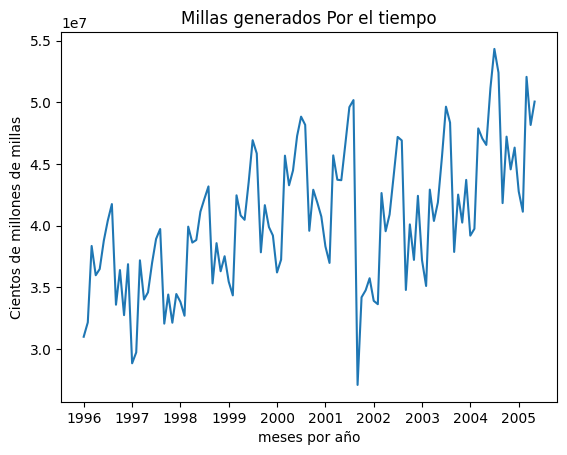

In [27]:
plt.plot(df.index, df["y"])
plt.title("Millas generados Por el tiempo")
plt.ylabel("Cientos de millones de millas")
plt.xlabel("meses por año")
plt.show()

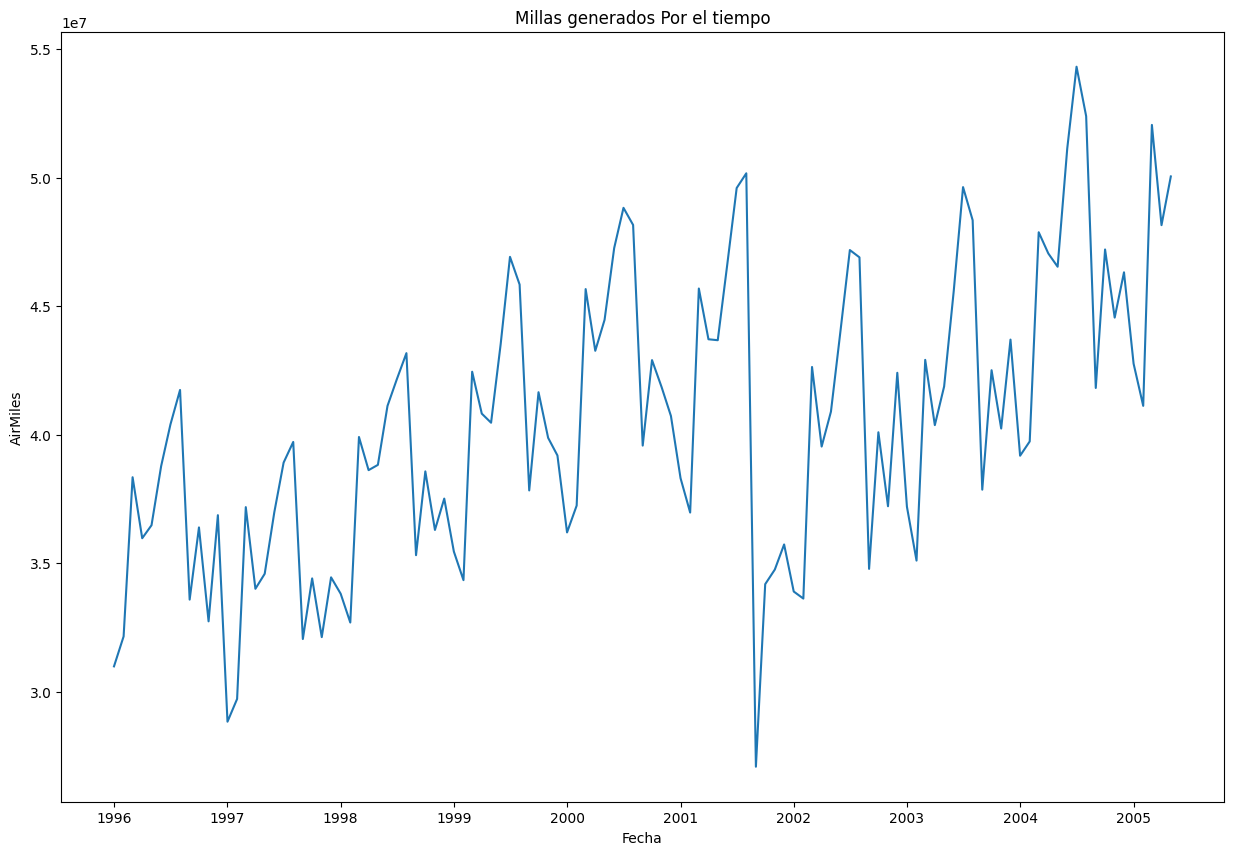

In [29]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
ax.set_title("Millas generados Por el tiempo")
ax.set_ylabel("AirMiles")
ax.set_xlabel("Fecha")
ax.plot(df)

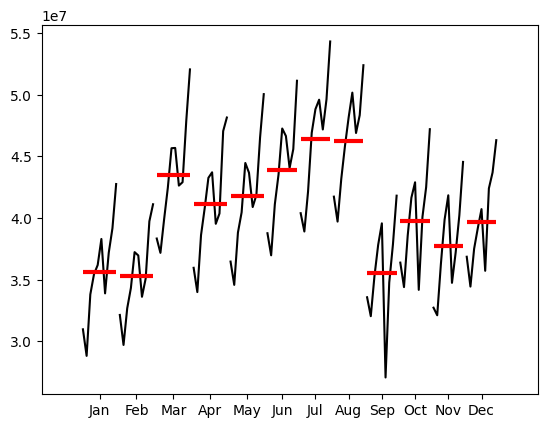

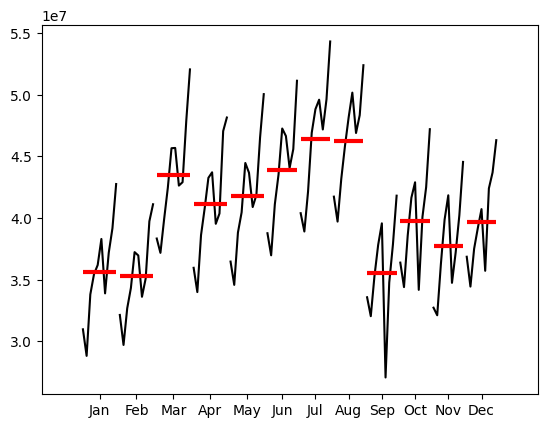

In [21]:
# Vamos a hacer el grafico mensual
month_plot(df['y'].resample(rule='MS').mean())

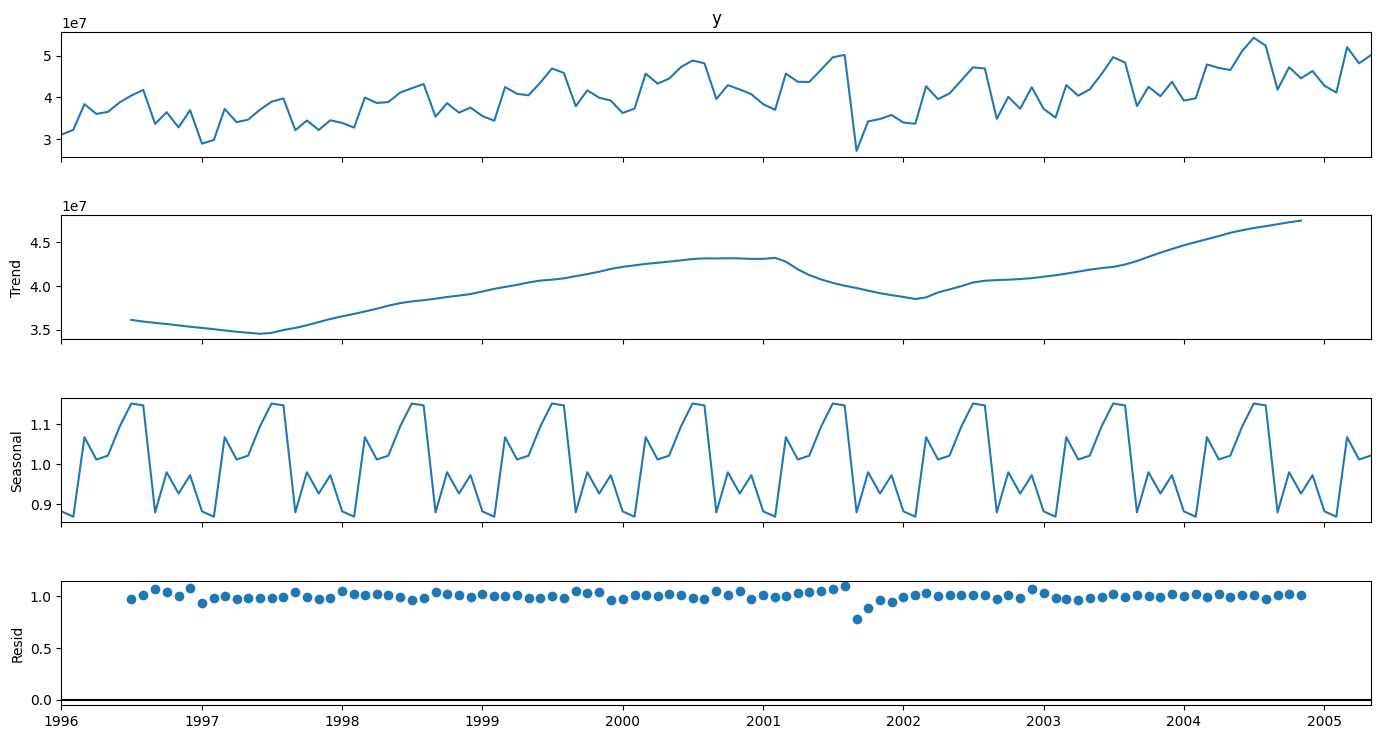

In [26]:
decomposition =  seasonal_decompose(x=df['y'], model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(15,8)
plt.show()

## Autocorrelacion y autocorrelacion parcial

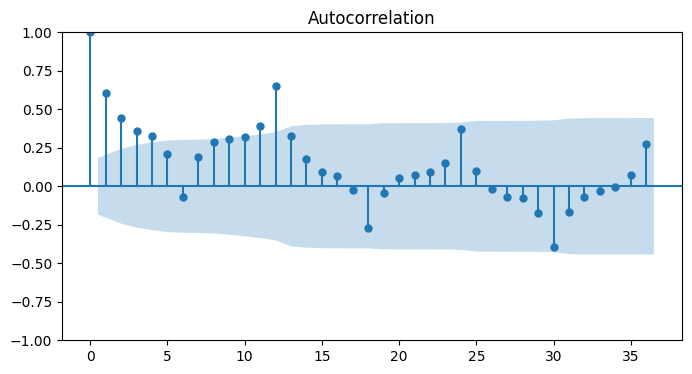

In [32]:
fig, ax = plt.subplots(figsize = (8,4))
plot_acf(df['y'], lags=36, ax=ax)
plt.show()

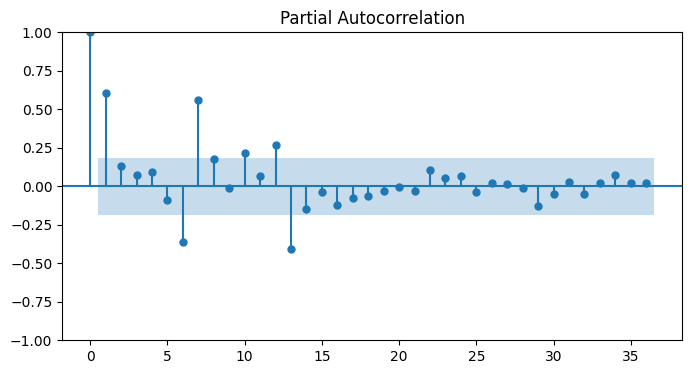

In [33]:
fig, ax = plt.subplots(figsize = (8,4))
plot_pacf(df['y'], lags=36, ax=ax)
plt.show()

## Entrenamiento/Validacion

In [42]:
#Separamos nuestro datos para entrenar y validar
# El objetivo será predecir las siguientes 6 meses
# Solo usamos la variable y

periods = 6
df_train = df[:-periods].y.to_frame()
df_test = df[-periods:].y.to_frame()

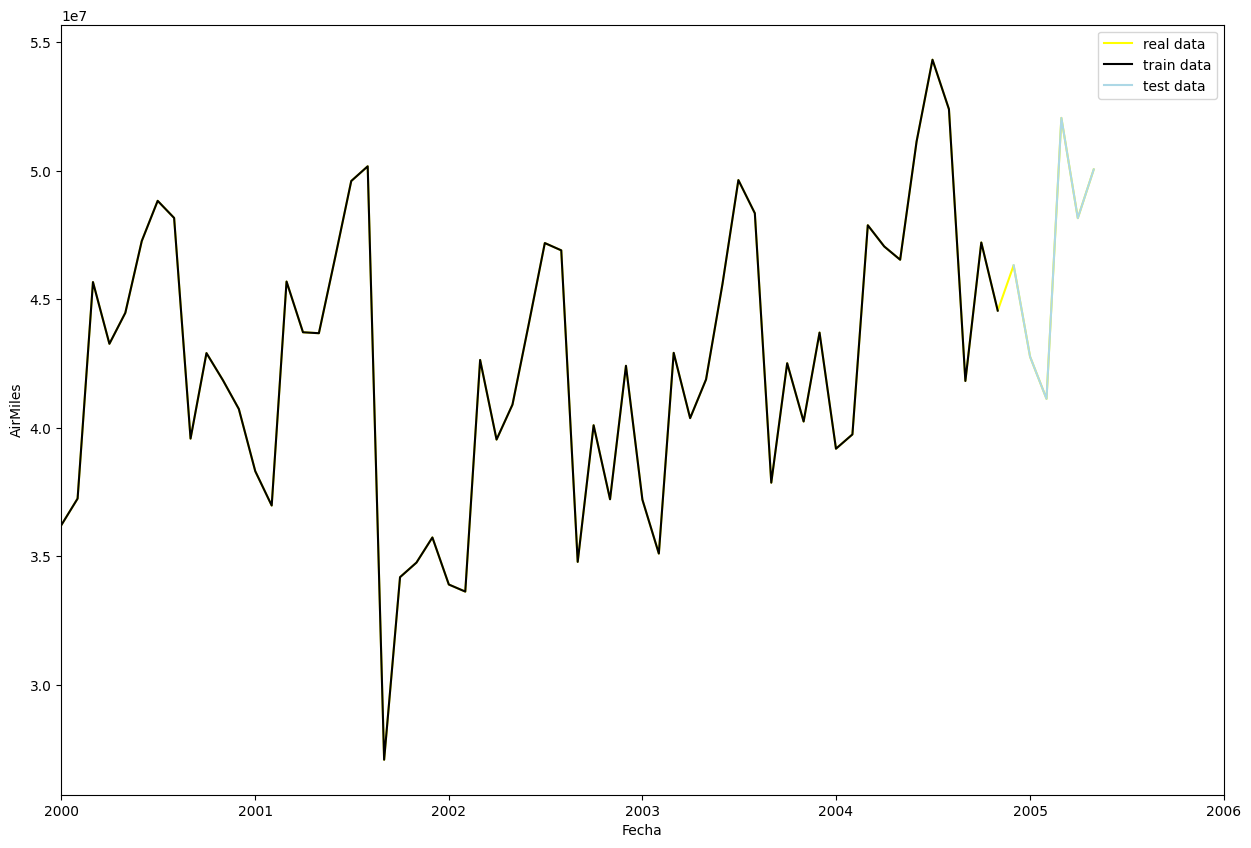

In [54]:
fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(111)
ax.plot(df.index, df['y'], color='yellow', label='real data')
ax.plot(df_train.index, df_train["y"], color='black', label='train data')
ax.plot(df_test.index, df_test["y"], color='lightblue', label='test data')
ax.set_xlabel("Fecha")
ax.set_ylabel("AirMiles")
ax.set_xlim("2000","2006")
ax.legend()

plt.show()

In [52]:
## Holt Winter (Suavizado exponencial triple)
model_holt = ExponentialSmoothing(
    endog=df_train,
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
).fit()
display(model_holt.summary())

/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Dep. Variable:,y,No. Observations:,107
Model:,ExponentialSmoothing,SSE,260736214419953.250
Optimized:,True,AIC,3083.822
Trend:,Multiplicative,BIC,3126.587
Seasonal:,Multiplicative,AICC,3091.595
Seasonal Periods:,12,Date:,"Thu, 30 Oct 2025"
Box-Cox:,False,Time:,10:38:01
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5328041,alpha,True
smoothing_trend,0.000000,beta,True


In [56]:
# Predicciones
periods=6
model_triple_pred = model_holt.forecast(periods)
model_triple_pred.to_frame()

,0
2004-12-01,4.672097e+07
2005-01-01,4.250114e+07
2005-02-01,4.217464e+07
2005-03-01,5.179306e+07
2005-04-01,4.923794e+07
2005-05-01,4.981930e+07


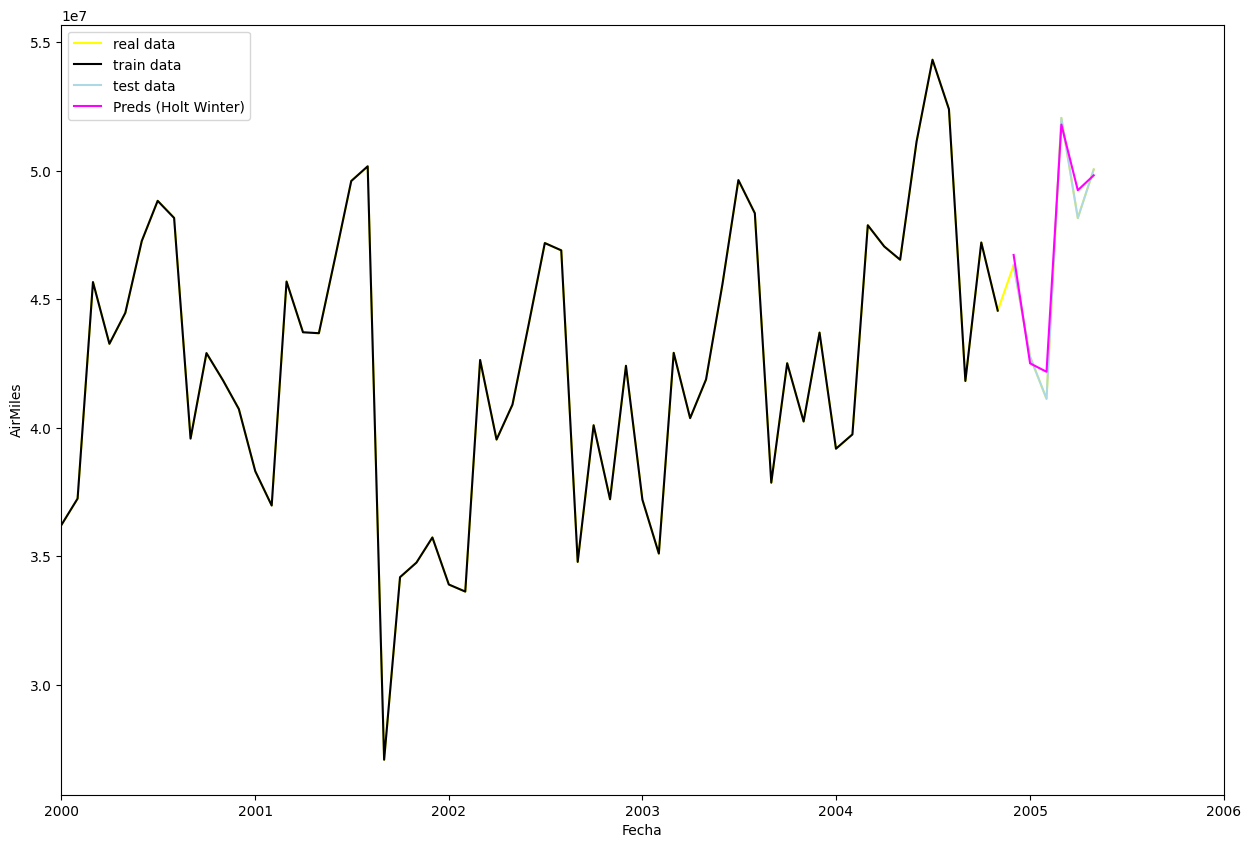

In [57]:
# Vizualizacion
fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(111)
ax.plot(df.index, df['y'], color='yellow', label='real data')
ax.plot(df_train.index, df_train["y"], color='black', label='train data')
ax.plot(df_test.index, df_test["y"], color='lightblue', label='test data')
ax.plot(model_triple_pred, label="Preds (Holt Winter)", color="magenta")
ax.set_xlabel("Fecha")
ax.set_ylabel("AirMiles")
ax.set_xlim("2000","2006")
ax.legend()

plt.show()

In [58]:
# Calculamos el RMSE, MAE y MAPE
rmse = root_mean_squared_error(df_test, model_triple_pred)
mae = mean_absolute_error(df_test, model_triple_pred)
mape = mean_absolute_percentage_error(df_test, model_triple_pred)

print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {100*mape:.1f} %")

RMSE: 663226
MAE: 548607
MAPE: 1.2 %


## Predecir a Futuro

In [60]:
# Construimos un modelo Winter Holt con todos los datos

model_holt_complete = ExponentialSmoothing(
    endog=df.y,
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
).fit()

/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [64]:
# Predecimos el futuro 
forecast = model_holt_complete.forecast(6)
forecast[:6]

2005-06-01    5.333950e+07
2005-07-01    5.645171e+07
2005-08-01    5.616236e+07
2005-09-01    4.298744e+07
2005-10-01    4.825183e+07
2005-11-01    4.579835e+07
Freq: MS, dtype: float64

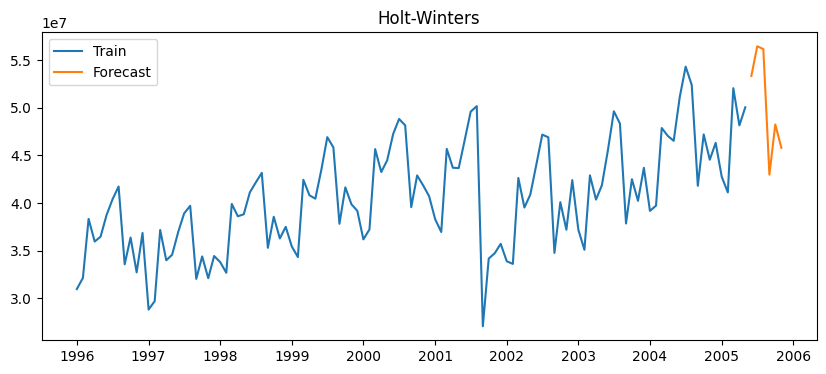

In [63]:
# Grafico para datos de entrenamiento y forecast
plt.figure(figsize=(10,4))

# Grafico entrenamiento, test y forecast
plt.plot(df.y, label="Train")
plt.plot(forecast, label="Forecast")

plt.title("Holt-Winters")
plt.legend()
plt.show()

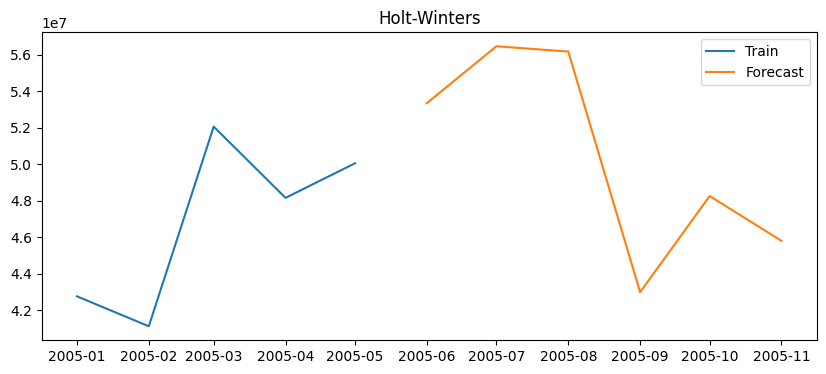

In [66]:
def plot_future(y,forecast,chart_title=None):
    # Grafico para datos de entrenamiento y forecast
    plt.figure(figsize=(10,4))
    
    # Grafico entrenamiento, test y forecast
    plt.plot(y, label="Train")
    plt.plot(forecast, label="Forecast")
    
    plt.title("Holt-Winters")
    plt.legend()
    plt.show()

plot_future(df["y"].loc["2005"],forecast,"Holt-Winters")